In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


7 Exercise.



Implement an End to End CNN Model for Image Classification Task.


Objective



In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.

Task 1: Data Understanding and Visualization:


Download the Provided Data and Complete the following task.



1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:
• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.

In [5]:
import os

train_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

Classes: ['tucuma', 'cupuacu', 'guarana', 'acai', 'pupunha', 'graviola']


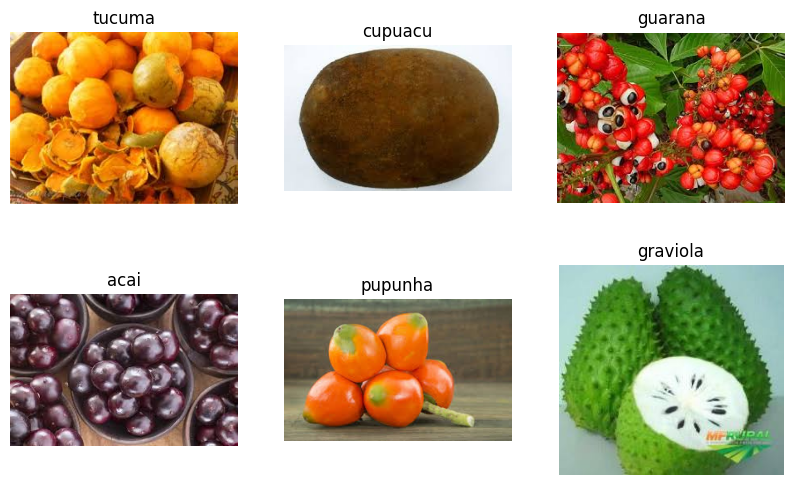

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)
print("Classes:", classes)

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    # Ensure there are files in the directory before trying to select one
    files_in_class = os.listdir(class_path)
    if not files_in_class:
        print(f"Warning: No files found in {class_path}, skipping.")
        continue

    img_name = random.choice(files_in_class)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Display only if images were successfully loaded
if images:
    plt.figure(figsize=(10,6))
    # Adjust number of columns based on number of images to ensure 2 rows
    num_cols = (len(images) + 1) // 2
    for i in range(len(images)):
        plt.subplot(2, num_cols, i+1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis("off")

    plt.show()
else:
    print("No images were loaded for visualization.")

• What did you Observe?

The dataset contains multiple fruit classes. Each class has different image variations such as lighting, angles, and backgrounds. This diversity helps improve model generalization.

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

In [7]:
from PIL import Image

corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


Task 2: Loading and Preprocessing Image Data in keras:



In this section, we will load and preprocess image data from a directory using the
image dataset from directory function in Keras.
This function is used to load images from a directory structure where subdirectories represent different


classes. We will also apply basic preprocessing, including resizing and batching and normalization of
images. The same function can be used to load train and validation data.

Load & Preprocess Data

In [8]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

Load training dataset

In [9]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


Load validation dataset

In [10]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


Normalize data

In [11]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Task 3 - Implement a CNN with

Build CNN Model

In [12]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 4: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam)

Compile Model

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Train the Model
Model Training



• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.
• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

Train Model

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # later increase if needed
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.1453 - loss: 1.9388

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 871ms/step - accuracy: 0.1389 - loss: 2.0073 - val_accuracy: 0.7778 - val_loss: 1.2633
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.3096 - loss: 1.6314

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 605ms/step - accuracy: 0.3194 - loss: 1.5997 - val_accuracy: 0.7778 - val_loss: 1.0852
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 530ms/step - accuracy: 0.4722 - loss: 1.2667 - val_accuracy: 0.5000 - val_loss: 1.5419
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5822 - loss: 1.0594

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.6528 - loss: 0.9798 - val_accuracy: 0.7222 - val_loss: 0.8045
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.7656 - loss: 0.7064

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.7500 - loss: 0.7149 - val_accuracy: 0.8889 - val_loss: 0.6067
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 793ms/step - accuracy: 0.8194 - loss: 0.5762 - val_accuracy: 0.8333 - val_loss: 0.6218
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9549 - loss: 0.2802

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 783ms/step - accuracy: 0.9583 - loss: 0.2893 - val_accuracy: 0.8889 - val_loss: 0.4536
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9797 - loss: 0.2218

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.9861 - loss: 0.2059 - val_accuracy: 0.8333 - val_loss: 0.4252
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 1.0000 - loss: 0.0971 - val_accuracy: 0.8333 - val_loss: 0.4900
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9803 - loss: 0.0809

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - accuracy: 0.9722 - loss: 0.0842 - val_accuracy: 0.8333 - val_loss: 0.3227
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 1.0000 - loss: 0.0303 - val_accuracy: 0.8889 - val_loss: 0.3619
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 0.8889 - val_loss: 0.4264
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 818ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 0.8333 - val_loss: 0.4281
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 669ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.8889 - val_loss: 0.3351
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 1.0000 - loss: 0.0033

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8889 - val_loss: 0.2766
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8889 - val_loss: 0.2929
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8889 - val_loss: 0.3503
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8333 - val_loss: 0.3893
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 1.0000 - loss: 7.4894e-04 - val_accuracy: 0.8889 - val_loss: 0.3859
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 658ms/step - accuracy: 1.0000 - loss: 4.4891e-04 - val_accuracy: 0.8889 - val_loss: 0.3847
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 887ms/step - accuracy: 1.0000 - loss: 3.2616e-04 - val_accuracy: 0.8889 - val_loss: 0.4044
Epoch 22/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 1.0000 - loss: 2.7678e-04 - val_accuracy: 0.8889

Plot Accuracy & Loss

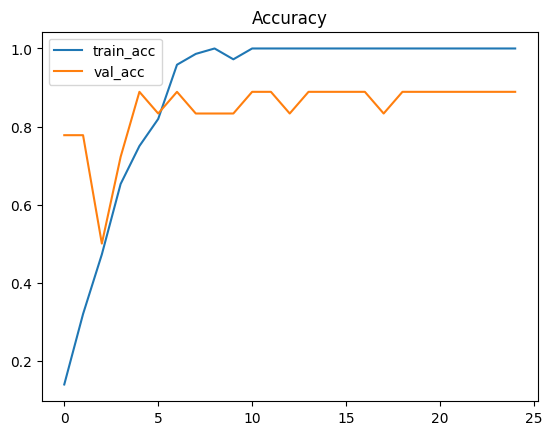

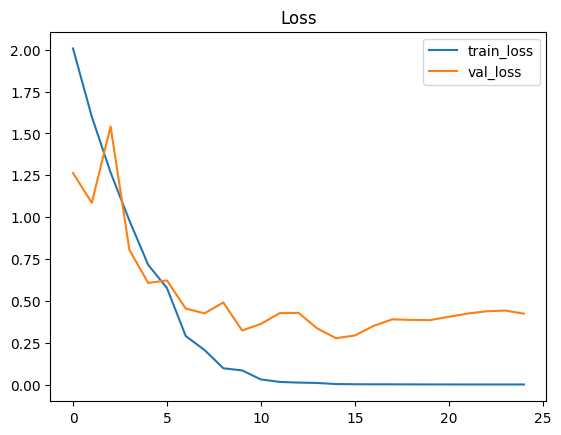

In [16]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

Task 6: Evaluate the Model

Model Evaluation

• After training, evaluate

In [17]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7000 - loss: 0.9207
Test Accuracy: 0.699999988079071


Task 7: Save and Load the Model
Model Saving and Loading




• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

Save & Load Model

In [18]:
model.save("fruit_model.h5")

# Load again
from tensorflow.keras.models import load_model

loaded_model = load_model("fruit_model.h5")

loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - accuracy: 0.7000 - loss: 0.9207


[0.920674741268158, 0.699999988079071]

Task 8: Predictions and Classification Report
Making Predictions




• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

Classification Report

In [19]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
              precision    recall  f1-score   support

      tucuma       0.67      0.80      0.73         5
     cupuacu       0.50      0.60      0.55         5
     guarana       0.71      1.00      0.83         5
        acai       0.67      0.80      0.73         5
     pupunha       1.00      0.60      0.75         5
    graviola       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.76      0.70      0.69        30
weighted avg       0.76      0.70      0.69        30

